# DATATHON 2026 - Phân tích khám phá dữ liệu cho tăng trưởng lợi nhuận

# Bước 1: Nhập dữ liệu đầu vào

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
import sys
import pandas as pd
sys.path.append("../src")

import data_loader

In [3]:
products = data_loader.load_products()
customers = data_loader.load_customers()
orders = data_loader.load_orders()
order_items = data_loader.load_order_items()
sales = data_loader.load_sales()
inventory = data_loader.load_inventory()
web_traffic = data_loader.load_web_traffic()
returns = data_loader.load_returns()
geography = data_loader.load_geography()
payments = data_loader.load_payments()

# 2. Kiểm tra tổng quan dữ liệu

In [4]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
 8   gross_margin  2412 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 169.7+ KB


In [25]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          121930 non-null  int64         
 1   zip                  121930 non-null  int64         
 2   city                 121930 non-null  object        
 3   signup_date          121930 non-null  datetime64[ns]
 4   gender               121930 non-null  object        
 5   age_group            121930 non-null  object        
 6   acquisition_channel  121930 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 6.5+ MB


In [26]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  object        
 5   payment_method  646945 non-null  object        
 6   device_type     646945 non-null  object        
 7   order_source    646945 non-null  object        
 8   order_year      646945 non-null  int32         
 9   order_month     646945 non-null  int32         
 10  order_quarter   646945 non-null  int32         
 11  order_dow       646945 non-null  object        
dtypes: datetime64[ns](1), int32(3), int64(3), object(5)
memory usage: 51.8+ MB


In [27]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  object 
 6   promo_id_2       206 non-null     object 
 7   line_revenue     714669 non-null  float64
 8   has_promo        714669 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 49.1+ MB


In [28]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          3833 non-null   datetime64[ns]
 1   Revenue       3833 non-null   float64       
 2   COGS          3833 non-null   float64       
 3   gross_profit  3833 non-null   float64       
 4   gross_margin  3833 non-null   float64       
 5   year          3833 non-null   int32         
 6   month         3833 non-null   int32         
 7   quarter       3833 non-null   int32         
 8   week          3833 non-null   int64         
 9   dow           3833 non-null   int32         
 10  is_weekend    3833 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int32(4), int64(2)
memory usage: 269.6 KB


In [29]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[ns]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  reorder_flag       60247 non-null  int64         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  object        
 13  category           60247 non-null  object        
 14  segmen

In [30]:
web_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[ns]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 199.8+ KB


In [31]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  object        
 1   order_id         39939 non-null  int64         
 2   product_id       39939 non-null  int64         
 3   return_date      39939 non-null  datetime64[ns]
 4   return_reason    39939 non-null  object        
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 2.1+ MB


In [32]:
geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   zip       39948 non-null  int64 
 1   city      39948 non-null  object
 2   region    39948 non-null  object
 3   district  39948 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [33]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  object 
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 19.7+ MB


Kiểm tra missing values

In [34]:
products.isnull().sum()

product_id      0
product_name    0
category        0
segment         0
size            0
color           0
price           0
cogs            0
gross_margin    0
dtype: int64

In [35]:
customers.isnull().sum()

customer_id            0
zip                    0
city                   0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64

In [36]:
orders.isnull().sum()

order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
order_year        0
order_month       0
order_quarter     0
order_dow         0
dtype: int64

In [37]:
order_items.isnull().sum()

order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
line_revenue            0
has_promo               0
dtype: int64

In [38]:
sales.isnull().sum()

Date            0
Revenue         0
COGS            0
gross_profit    0
gross_margin    0
year            0
month           0
quarter         0
week            0
dow             0
is_weekend      0
dtype: int64

In [39]:
inventory.isnull().sum()

snapshot_date        0
product_id           0
stock_on_hand        0
units_received       0
units_sold           0
stockout_days        0
days_of_supply       0
fill_rate            0
stockout_flag        0
overstock_flag       0
reorder_flag         0
sell_through_rate    0
product_name         0
category             0
segment              0
year                 0
month                0
dtype: int64

In [40]:
web_traffic.isnull().sum()

date                        0
sessions                    0
unique_visitors             0
page_views                  0
bounce_rate                 0
avg_session_duration_sec    0
traffic_source              0
dtype: int64

In [41]:
returns.isnull().sum()

return_id          0
order_id           0
product_id         0
return_date        0
return_reason      0
return_quantity    0
refund_amount      0
dtype: int64

In [42]:
payments.isnull().sum()

order_id          0
payment_method    0
payment_value     0
installments      0
dtype: int64

# 3. Tổng quan nhanh về dữ liệu

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = {
    "black": "#171717",
    "dark_gray": "#2B2B2B",
    "green": "#8CFF5A",
    "lime_green": "#A3FF6A",
    "white": "#FFFFFF",
    "light_gray": "#F2F4F3",
    "mid_gray": "#B8B8B8",
    "risk_red": "#FF5A5F",
    "warning": "#FFB020",
    "info_blue": "#4DA3FF",
    "base_bar": "#5A6472",
}


def count_frame(series, label):
    df_count = series.value_counts().reset_index()
    df_count.columns = [label, "count"]
    return df_count


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_count_chart(
    df,
    column,
    label,
    title,
    top_n=None,
    horizontal=False,
    color="base_bar",
    rotation=0,
    figsize=(10, 6),
    show_value=True
):

    # ===== DATA =====
    data = count_frame(df[column], label)

    if top_n:
        data = data.head(top_n)

    data = data.sort_values("count", ascending=False)

    # ===== FIGURE =====
    fig, ax = plt.subplots(figsize=figsize)

    # ===== PLOT =====
    sns.barplot(
        data=data,
        x="count" if horizontal else label,
        y=label if horizontal else "count",
        color=PALETTE[color],
        ax=ax
    )

    # ===== VALUE LABELS (FIX CHUẨN) =====
    if show_value:
        for p in ax.patches:
            if horizontal:
                ax.text(
                    p.get_width(),
                    p.get_y() + p.get_height() / 2,
                    int(p.get_width()),
                    va="center",
                    ha="left",
                    color="black"
                )
            else:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    p.get_height(),
                    int(p.get_height()),
                    ha="center",
                    va="bottom",
                    color="black"
                )

    # ===== STYLE =====
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=rotation)

    clean_axis(ax)

    ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7, color='gray')
    ax.set_axisbelow(True)

    if not horizontal:
        ax.set_ylim(0, data["count"].max() * 1.1)

    plt.tight_layout()
    plt.show()

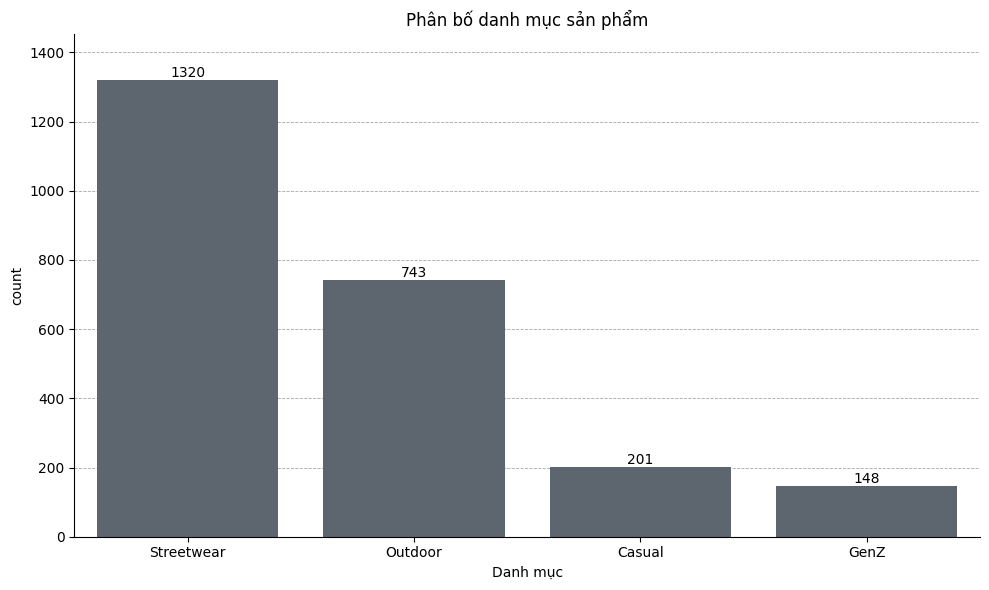

In [41]:
plot_count_chart(
    df=products,
    column="category",
    label="Danh mục",
    title="Phân bố danh mục sản phẩm"
)

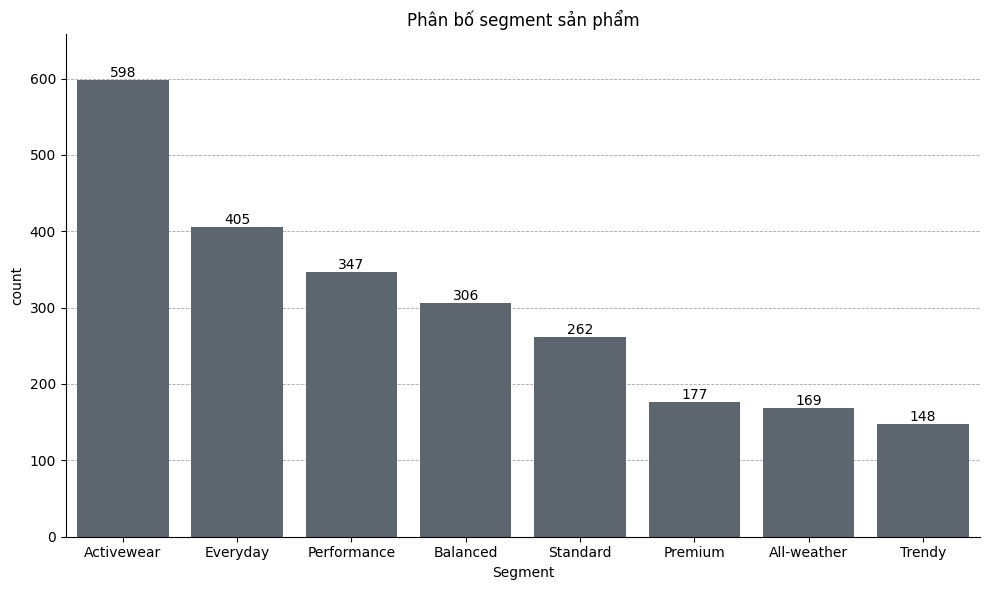

In [43]:
plot_count_chart(
    df=products,
    column="segment",
    label="Segment",
    title="Phân bố segment sản phẩm"
)

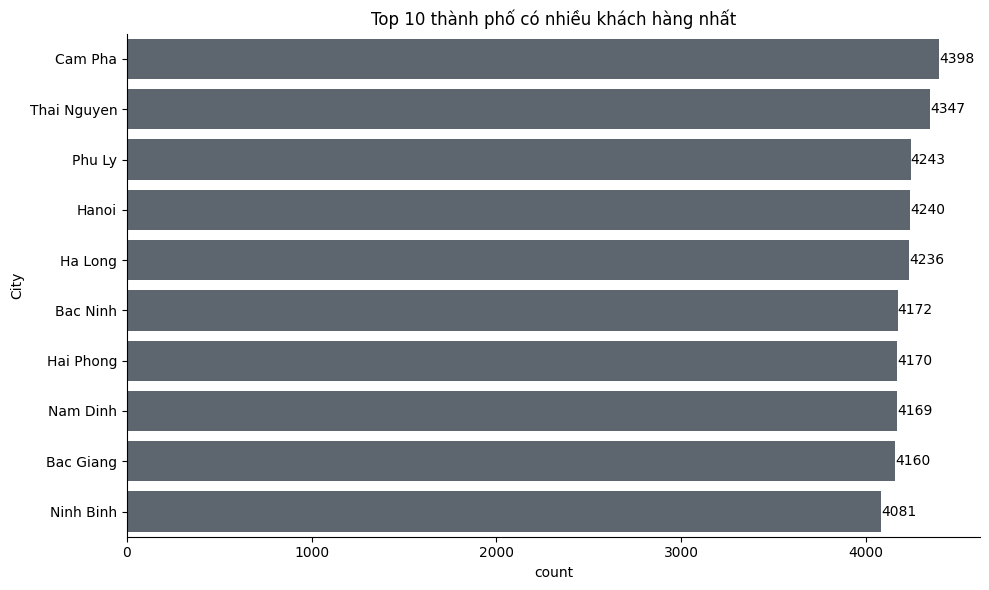

In [36]:
plot_count_chart(
    df=customers,
    column="city",
    label="City",
    title="Top 10 thành phố có nhiều khách hàng nhất",
    top_n=10,
    horizontal=True
)

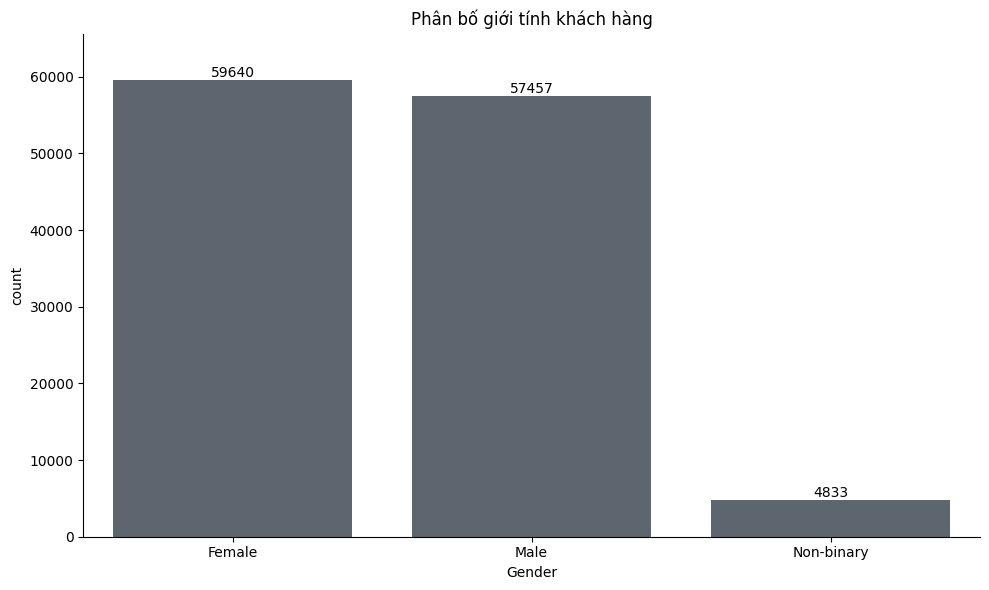

In [37]:
plot_count_chart(
    df=customers,
    column="gender",
    label="Gender",
    title="Phân bố giới tính khách hàng"
)

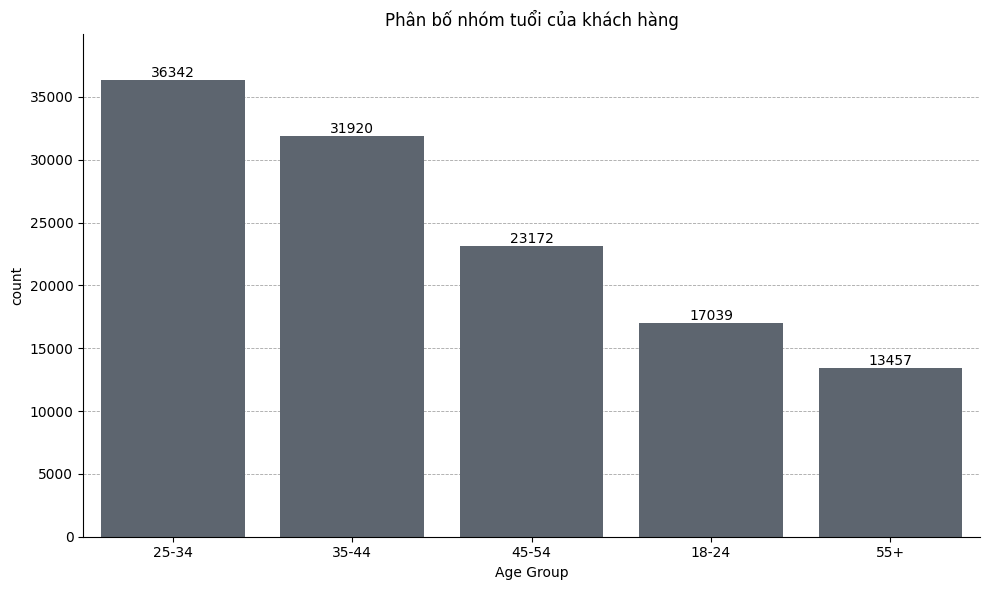

In [47]:
plot_count_chart(
    df=customers,
    column="age_group",
    label="Age Group",
    title="Phân bố nhóm tuổi của khách hàng"
)

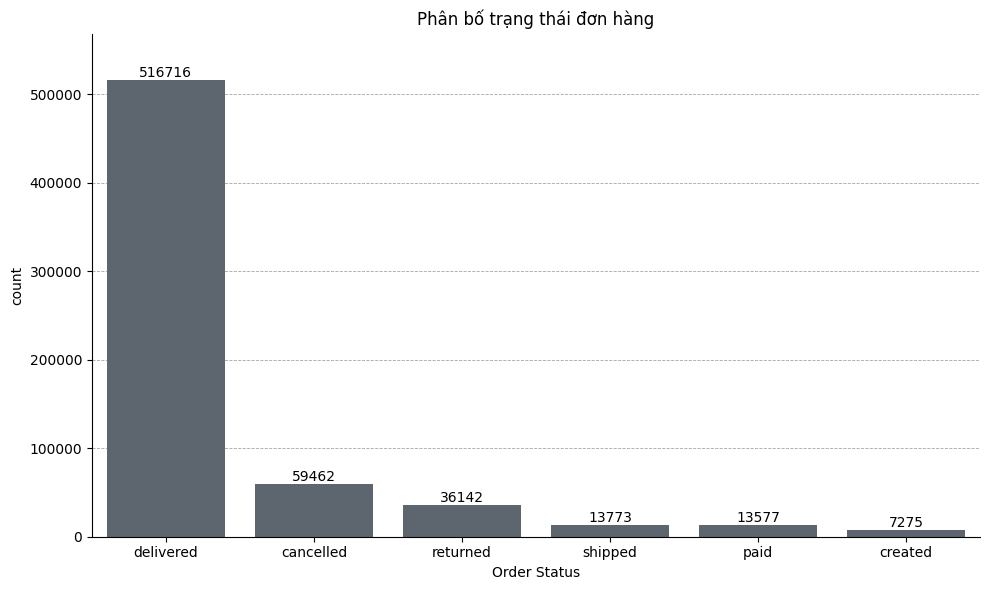

In [46]:
plot_count_chart(
    df=orders,
    column="order_status",
    label="Order Status",
    title="Phân bố trạng thái đơn hàng"
)

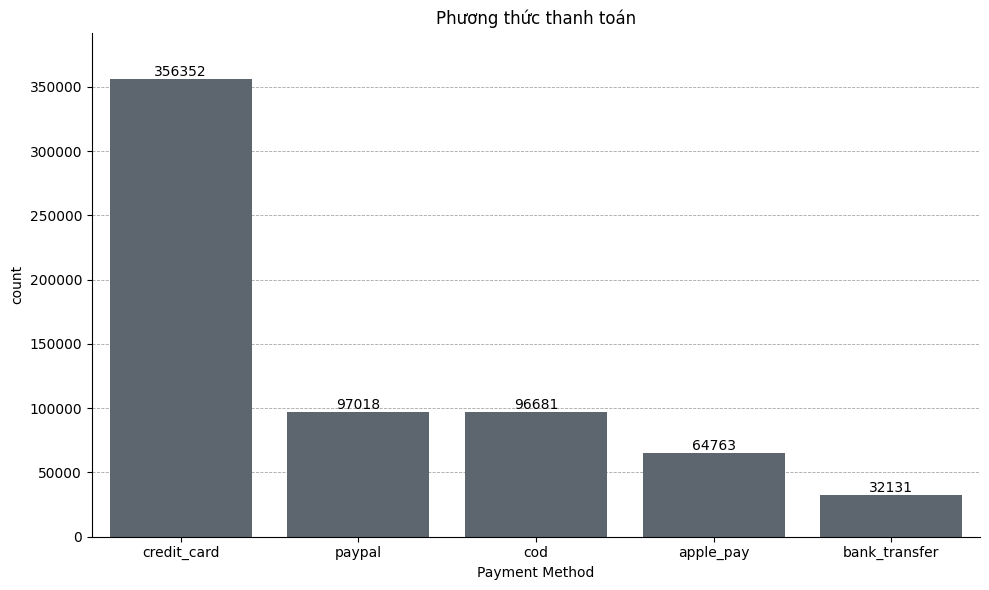

In [48]:
plot_count_chart(
    df=payments,
    column="payment_method",
    label="Payment Method",
    title="Phương thức thanh toán"
)

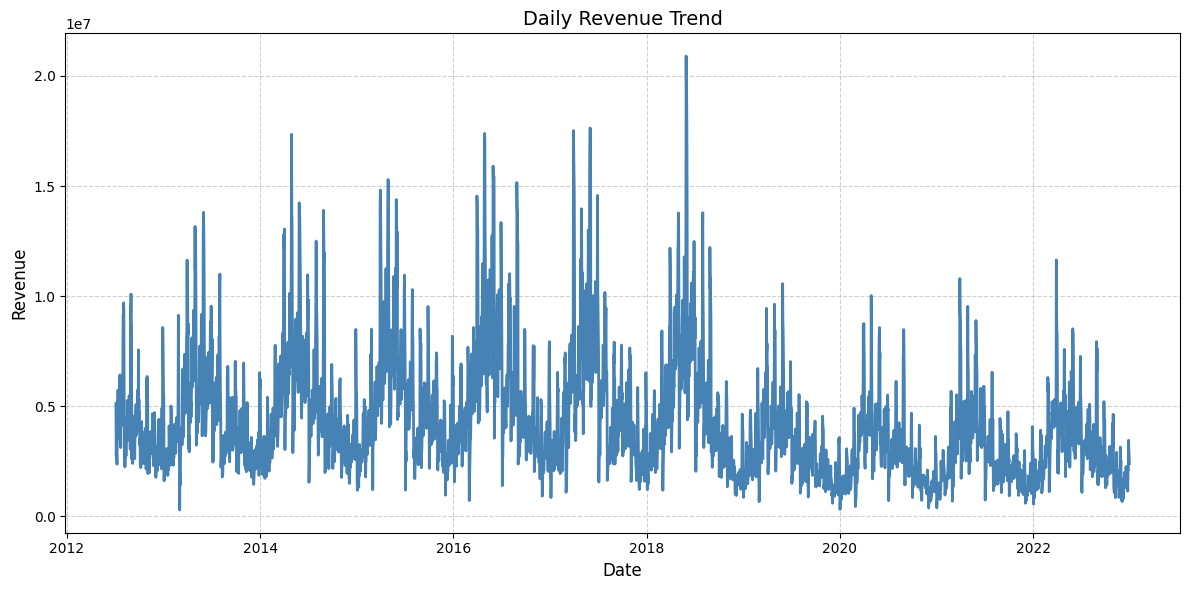

In [19]:
sales['Date'] = pd.to_datetime(sales['Date'])

daily_sales = sales.groupby('Date')['Revenue'].sum()

plt.figure(figsize=(12,6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    color="steelblue",
    linewidth=2
)

plt.title("Daily Revenue Trend", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

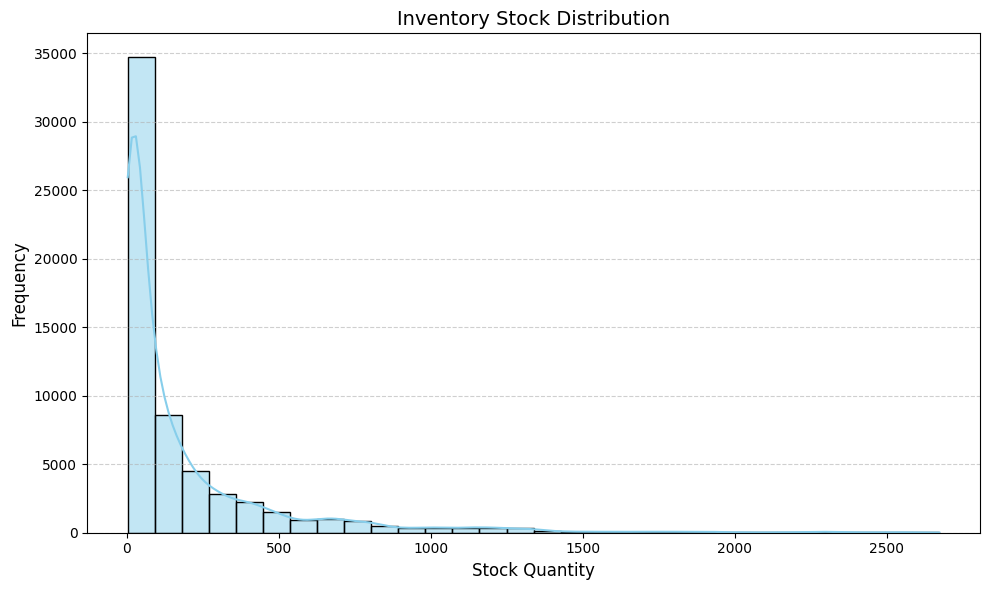

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    inventory['stock_on_hand'],
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Inventory Stock Distribution", fontsize=14)
plt.xlabel("Stock Quantity", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

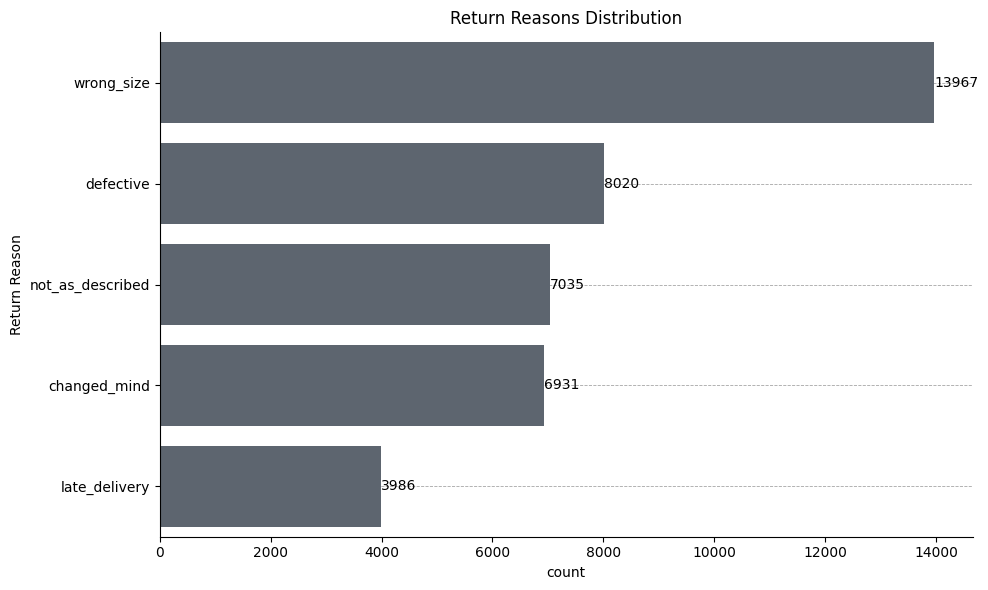

In [ ]:
plot_count_chart(
    df=returns,
    column="return_reason",
    label="Return Reason",
    title="Lý do trả hàng",
    horizontal=True
)

# Phân tích dữ liệu bảng sales

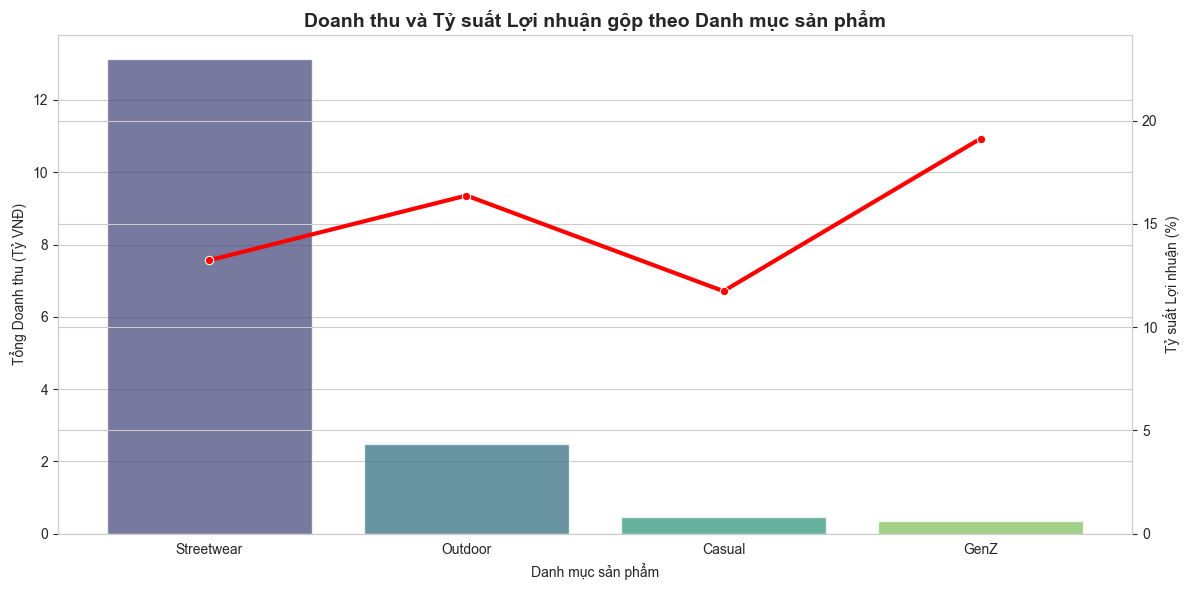

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# =========================
# 1. FORMAT TRỤC Y (TỶ VNĐ)
# =========================
def billions_formatter(x, pos):
    return f'{x / 1e9:,.0f}'


# =========================
# 2. MERGE + FEATURE ENGINEERING
# =========================

# merge order_items với products (lấy category + cogs)
df = order_items.merge(
    products[['product_id', 'category', 'cogs']],
    on='product_id',
    how='left'
)

# doanh thu dòng
df['line_revenue'] = df['unit_price'] * df['quantity']

# giá vốn dòng
df['line_cogs'] = df['cogs'] * df['quantity']

# lợi nhuận dòng
df['line_profit'] = df['line_revenue'] - df['line_cogs']


# =========================
# 3. AGGREGATE THEO CATEGORY
# =========================
cat_analysis = df.groupby('category').agg(
    Total_Revenue=('line_revenue', 'sum'),
    Total_Profit=('line_profit', 'sum')
).reset_index()

cat_analysis['Margin_Rate'] = (
    cat_analysis['Total_Profit'] / cat_analysis['Total_Revenue']
) * 100

cat_analysis = cat_analysis.sort_values('Total_Revenue', ascending=False)


# =========================
# 4. VISUALIZATION
# =========================
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# ---- Bar: Revenue
ax = sns.barplot(
    data=cat_analysis,
    x='category',
    y='Total_Revenue',
    hue='category',
    palette='viridis',
    alpha=0.75,
    legend=False
)

# ---- Line: Margin Rate
ax2 = ax.twinx()
sns.lineplot(
    data=cat_analysis,
    x='category',
    y='Margin_Rate',
    color='red',
    marker='o',
    linewidth=3,
    ax=ax2
)

# =========================
# 5. FORMAT AXES
# =========================
ax.yaxis.set_major_formatter(FuncFormatter(billions_formatter))

ax.set_title(
    'Doanh thu và Tỷ suất Lợi nhuận gộp theo Danh mục sản phẩm',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Danh mục sản phẩm')
ax.set_ylabel('Tổng Doanh thu (Tỷ VNĐ)')
ax2.set_ylabel('Tỷ suất Lợi nhuận (%)')

ax2.set_ylim(0, cat_analysis['Margin_Rate'].max() + 5)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1. Insight Explanation (Phân tích từ dữ liệu → câu chuyện kinh doanh)

Dữ liệu theo danh mục sản phẩm cho thấy một cấu trúc doanh thu đang “lệch” giữa quy mô tăng trưởng (Revenue Scale) và hiệu quả sinh lời (Profit Efficiency), phản ánh rõ sự mất cân bằng trong chiến lược danh mục hiện tại.

🔵 Streetwear – “động cơ tăng trưởng nhưng hiệu suất thấp”

Streetwear đang đóng vai trò gần như tuyệt đối trong cơ cấu doanh thu khi chiếm phần lớn tổng doanh thu toàn doanh nghiệp (xấp xỉ 80%, tương đương khoảng 13 tỷ VNĐ).

Tuy nhiên, điều đáng chú ý là biên lợi nhuận lại không tương xứng, chỉ dao động khoảng 15%. Điều này cho thấy:

Chi phí hàng bán (COGS) cao
Hoặc mức độ phụ thuộc lớn vào giảm giá / khuyến mãi

=> Streetwear đang “kéo doanh thu lên nhưng không kéo lợi nhuận lên tương ứng”, tạo ra hiện tượng tăng trưởng thiếu hiệu quả.

🟢 GenZ – “tài sản lợi nhuận chưa được khai thác”

Ngược lại hoàn toàn với Streetwear, GenZ là một phân khúc có quy mô doanh thu nhỏ nhất (~0.4 tỷ VNĐ), nhưng lại sở hữu biên lợi nhuận cao nhất (~20%).

Điều này phản ánh một insight quan trọng:

Đây là nhóm khách hàng có khả năng chi trả tốt
Hoặc sản phẩm có cấu trúc chi phí tối ưu hơn
Hoặc ít phụ thuộc vào discount

=> GenZ đang là một “profit pocket” bị bỏ ngỏ thay vì được mở rộng quy mô.

🟡 Outdoor – “phân khúc cân bằng và ổn định”

Outdoor nằm ở vị trí trung gian, với doanh thu khoảng 2.5 tỷ VNĐ và biên lợi nhuận ổn định (~17–18%).

Điểm đáng chú ý:

Không quá phụ thuộc vào volume
Không bị bào mòn lợi nhuận mạnh
Vận hành tương đối hiệu quả

=> Đây là nhóm mang tính “ổn định tài chính”, phù hợp vai trò cân bằng danh mục.

🔴 Casual – “phân khúc kém hiệu quả”

Casual thể hiện hiệu suất thấp ở cả hai chiều:

Doanh thu thấp (~0.5 tỷ VNĐ)
Biên lợi nhuận thấp (~12%)

Điều này thường xuất phát từ một trong các nguyên nhân:

Sản phẩm thiếu khác biệt
Sai định vị thị trường
Hoặc cấu trúc chi phí đầu vào không cạnh tranh

=> Casual đang là điểm yếu trong toàn bộ danh mục sản phẩm.

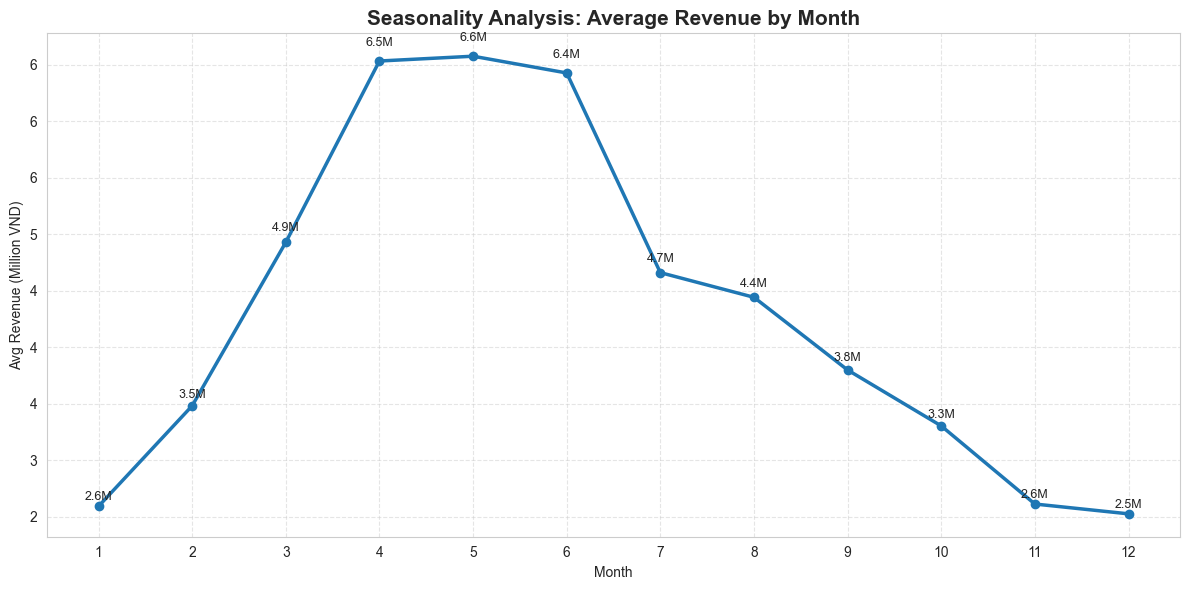

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# =========================
# 1. CONFIG PATH
# =========================
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"

os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)


# =========================
# 2. LOAD DATA (THEO STYLE CỦA BẠN)
# =========================
df_sales = data_loader.load_sales()   # nếu bạn có loader
# hoặc fallback:
# df_sales = pd.read_csv(f"{RAW_PATH}sales.csv")

df_sales['Date'] = pd.to_datetime(df_sales['Date'])


# =========================
# 3. FEATURE ENGINEERING
# =========================
df_sales['Month'] = df_sales['Date'].dt.month


monthly_seasonality = df_sales.groupby('Month').agg(
    Avg_Revenue=('Revenue', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Order_Count=('Revenue', 'count')
).reset_index()

monthly_seasonality = monthly_seasonality.sort_values('Month')

# save table
monthly_seasonality.to_csv(
    f"{TABLE_OUTPUT}05_monthly_seasonality.csv",
    index=False
)


# =========================
# 4. FORMAT FUNCTION
# =========================
def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}'


# =========================
# 5. VISUALIZATION
# =========================
plt.figure(figsize=(12, 6))

ax = plt.gca()

# line chart
ax.plot(
    monthly_seasonality['Month'],
    monthly_seasonality['Avg_Revenue'],
    marker='o',
    linewidth=2.5
)

ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

ax.set_title(
    'Seasonality Analysis: Average Revenue by Month',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Month')
ax.set_ylabel('Avg Revenue (Million VND)')

ax.set_xticks(range(1, 13))
ax.grid(True, linestyle='--', alpha=0.5)

# =========================
# 6. LABEL PEAK / LOW POINT
# =========================
for x, y in zip(monthly_seasonality['Month'], monthly_seasonality['Avg_Revenue']):
    ax.text(
        x,
        y * 1.02,
        f"{y/1e6:.1f}M",
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

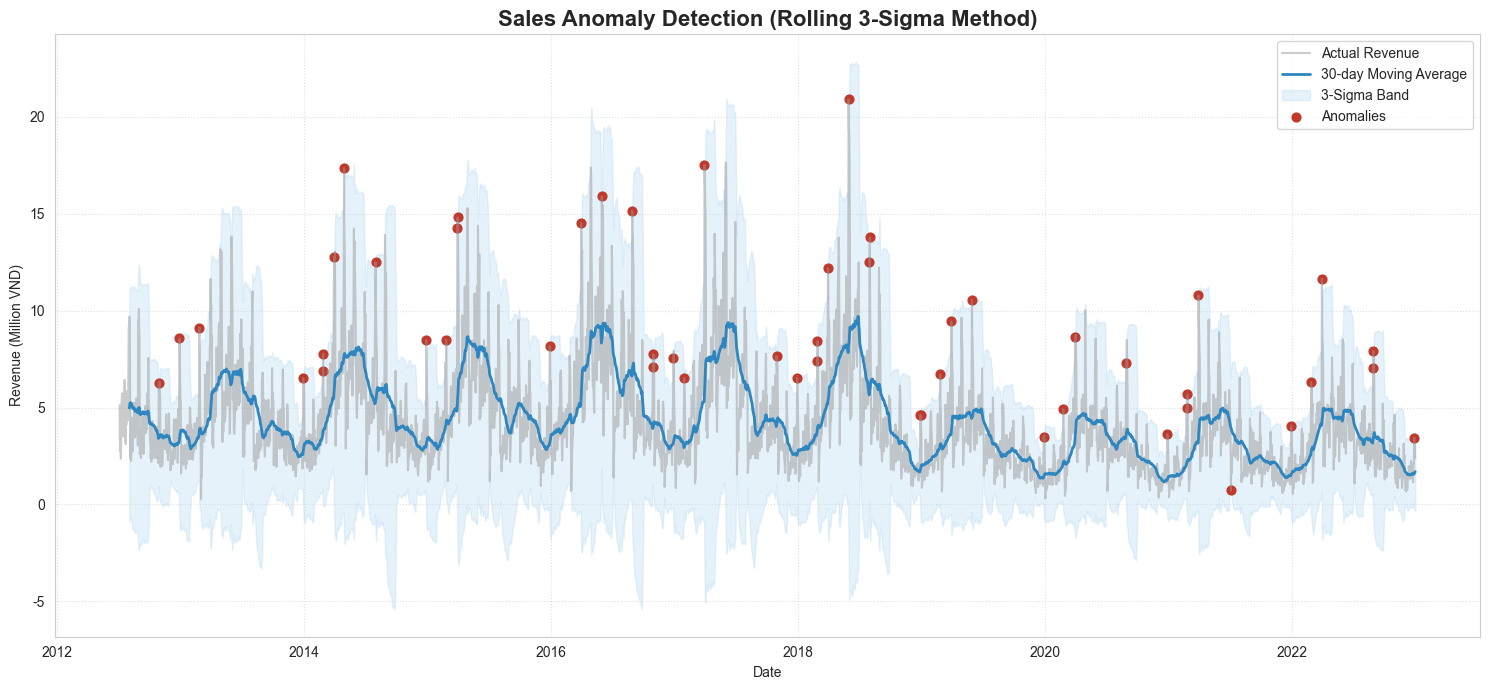

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =========================
# 1. FORMAT
# =========================
def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}'


# =========================
# 2. LOAD DATA
# =========================
df_sales = pd.read_csv("../data/sales.csv")

df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date').reset_index(drop=True)


# =========================
# 3. ANOMALY DETECTION (3-SIGMA ROLLING)
# =========================
WINDOW = 30

df_sales['Rolling_Mean'] = df_sales['Revenue'].rolling(WINDOW).mean()
df_sales['Rolling_Std'] = df_sales['Revenue'].rolling(WINDOW).std()

df_sales['Upper_Bound'] = df_sales['Rolling_Mean'] + 3 * df_sales['Rolling_Std']
df_sales['Lower_Bound'] = df_sales['Rolling_Mean'] - 3 * df_sales['Rolling_Std']

df_sales['Is_Outlier'] = (
    (df_sales['Revenue'] > df_sales['Upper_Bound']) |
    (df_sales['Revenue'] < df_sales['Lower_Bound'])
)


# =========================
# 4. VISUALIZATION
# =========================
plt.figure(figsize=(15, 7))

# actual revenue
plt.plot(
    df_sales['Date'],
    df_sales['Revenue'],
    color='#999999',
    alpha=0.5,
    label='Actual Revenue'
)

# rolling mean
plt.plot(
    df_sales['Date'],
    df_sales['Rolling_Mean'],
    color='#2E86C1',
    linewidth=2,
    label='30-day Moving Average'
)

# confidence band
plt.fill_between(
    df_sales['Date'],
    df_sales['Lower_Bound'],
    df_sales['Upper_Bound'],
    color='#AED6F1',
    alpha=0.3,
    label='3-Sigma Band'
)

# anomalies
outliers = df_sales[df_sales['Is_Outlier']]

plt.scatter(
    outliers['Date'],
    outliers['Revenue'],
    color='#C0392B',
    s=40,
    label='Anomalies'
)


# =========================
# 5. FORMATTING
# =========================
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.title(
    'Sales Anomaly Detection (Rolling 3-Sigma Method)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Revenue (Million VND)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

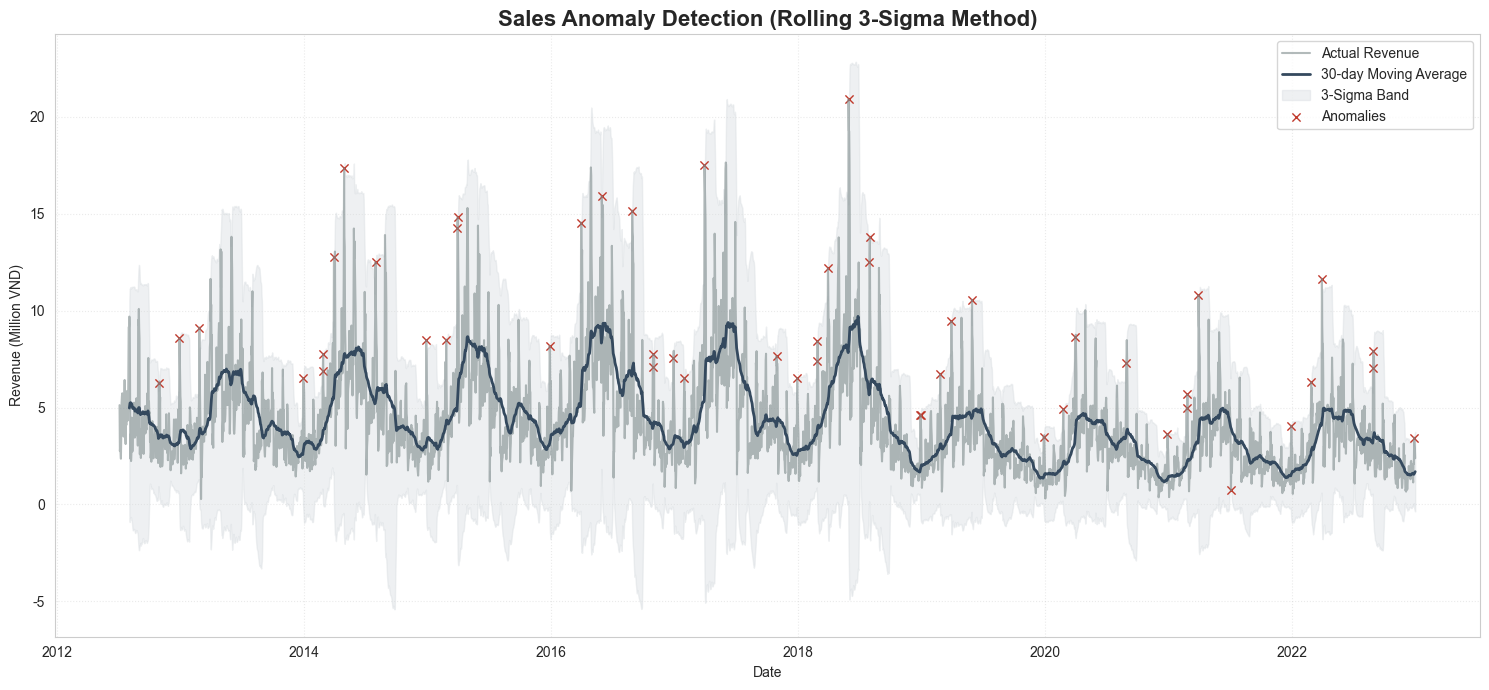

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =========================
# 1. FORMAT
# =========================
def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}'


# =========================
# 2. LOAD DATA
# =========================
df_sales = pd.read_csv("../data/sales.csv")

df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date').reset_index(drop=True)


# =========================
# 3. ANOMALY DETECTION
# =========================
WINDOW = 30

df_sales['Rolling_Mean'] = df_sales['Revenue'].rolling(WINDOW).mean()
df_sales['Rolling_Std'] = df_sales['Revenue'].rolling(WINDOW).std()

df_sales['Upper_Bound'] = df_sales['Rolling_Mean'] + 3 * df_sales['Rolling_Std']
df_sales['Lower_Bound'] = df_sales['Rolling_Mean'] - 3 * df_sales['Rolling_Std']

df_sales['Is_Outlier'] = (
    (df_sales['Revenue'] > df_sales['Upper_Bound']) |
    (df_sales['Revenue'] < df_sales['Lower_Bound'])
)


# =========================
# 4. VISUALIZATION
# =========================
plt.figure(figsize=(15, 7))

# actual revenue (neutral gray-blue)
plt.plot(
    df_sales['Date'],
    df_sales['Revenue'],
    color='#7F8C8D',
    alpha=0.6,
    label='Actual Revenue'
)

# rolling mean (dark blue muted)
plt.plot(
    df_sales['Date'],
    df_sales['Rolling_Mean'],
    color='#34495E',
    linewidth=2,
    label='30-day Moving Average'
)

# confidence band (light gray-blue)
plt.fill_between(
    df_sales['Date'],
    df_sales['Lower_Bound'],
    df_sales['Upper_Bound'],
    color='#D6DBDF',
    alpha=0.4,
    label='3-Sigma Band'
)

# =========================
# 5. ANOMALY MARKING (SUBTLE)
# =========================
outliers = df_sales[df_sales['Is_Outlier']]

plt.scatter(
    outliers['Date'],
    outliers['Revenue'],
    color='#C0392B',
    marker='x',
    s=35,
    linewidths=1,
    label='Anomalies'
)


# =========================
# 6. FORMAT
# =========================
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.title(
    'Sales Anomaly Detection (Rolling 3-Sigma Method)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Revenue (Million VND)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

1. Insight Explanation (Phân tích hành vi bất thường của doanh thu)

Biểu đồ sử dụng phương pháp Rolling Z-score với ngưỡng 3-Sigma và cửa sổ trượt 30 ngày nhằm tách biệt giữa biến động thông thường của doanh thu và các điểm bất thường mang tính hệ thống. Cách tiếp cận này cho phép quan sát rõ hơn “hành vi thật” của doanh nghiệp thay vì bị nhiễu bởi dao động hàng ngày.

Trước hết, có thể thấy một hiện tượng nổi bật là sự xuất hiện dày đặc của các spike doanh thu vượt ngưỡng trên (Upper Bound). Các điểm bất thường này không phân bố ngẫu nhiên mà có xu hướng tập trung theo chu kỳ, đặc biệt rõ vào các giai đoạn giữa năm (thường rơi vào quý 2). Điều này cho thấy doanh nghiệp có khả năng tận dụng tốt các thời điểm nhu cầu tăng cao của thị trường, tạo ra những đợt bùng nổ doanh thu vượt xa mức kỳ vọng thống kê. Về bản chất, đây là dấu hiệu tích cực, phản ánh hiệu quả của chiến lược marketing theo mùa hoặc các chiến dịch kích cầu có độ chính xác tốt.

Bên cạnh các điểm tăng đột biến, biểu đồ cũng ghi nhận một số cú sốc sụt giảm mạnh (downward spikes), trong đó đáng chú ý là một điểm rơi rất sâu quanh giai đoạn 2021, khi doanh thu tiệm cận mức gần như bằng 0. Đây không còn là biến động thị trường thông thường mà mang đặc trưng của một sự cố vận hành nghiêm trọng. Các khả năng hợp lý bao gồm gián đoạn hệ thống thanh toán, tình trạng hết hàng diện rộng (stockout), hoặc disruption trong chuỗi cung ứng và logistics. Đây là loại rủi ro “systemic risk” cần được ưu tiên xử lý vì tác động trực tiếp đến dòng tiền ngắn hạn.

Một điểm quan trọng khác là sự mở rộng dần của dải biến động (volatility band widening) về cuối chu kỳ dữ liệu. Dải 3-Sigma ngày càng rộng cho thấy độ phân tán doanh thu tăng lên theo thời gian. Điều này thường phản ánh hai khả năng: hoặc doanh nghiệp đang mở rộng quy mô sang nhiều phân khúc khách hàng hơn, hoặc hệ thống vận hành trở nên phức tạp hơn dẫn đến khó kiểm soát biến động. Dù theo hướng nào, đây cũng là tín hiệu cho thấy khả năng dự báo doanh thu đang trở nên kém ổn định hơn nếu không có cơ chế kiểm soát tốt.

Tổng hợp lại, doanh thu của doanh nghiệp không chỉ mang tính mùa vụ rõ ràng mà còn tồn tại các cú sốc mang tính hệ thống, bao gồm cả cơ hội (spikes) và rủi ro (drops). Điều này cho thấy doanh nghiệp đang vận hành trong một môi trường tăng trưởng nhưng chưa hoàn toàn ổn định về mặt kiểm soát rủi ro vận hành.

2. Business Recommendation (Đề xuất chiến lược dựa trên dữ liệu)

Từ các đặc điểm quan sát được, có thể xây dựng hai hướng hành động chính: khai thác cơ hội tăng trưởng và giảm thiểu rủi ro vận hành.

Trước hết, đối với các điểm spike doanh thu, doanh nghiệp không nên xem đây chỉ là hiện tượng ngẫu nhiên mà cần chuyển hóa chúng thành tài sản chiến lược. Cụ thể, cần thực hiện phân tích ngược (backtracking) các ngày có doanh thu đột biến để xác định nguyên nhân gốc rễ, bao gồm nguồn traffic, kênh marketing, sản phẩm liên quan và các yếu tố thúc đẩy như mã khuyến mãi hoặc chiến dịch truyền thông. Nếu xác định được các mẫu hình lặp lại (ví dụ spike đến từ organic search hoặc social campaign), doanh nghiệp có thể chuẩn hóa chúng thành “growth playbook” nhằm tái sử dụng trong các chu kỳ kinh doanh tiếp theo. Điều này giúp biến tăng trưởng ngẫu nhiên thành tăng trưởng có thể tái tạo.

Đối với các cú sụt giảm bất thường, ưu tiên hàng đầu là xây dựng hệ thống cảnh báo sớm (early warning system). Khi doanh thu theo thời gian thực rơi xuống dưới ngưỡng Lower Bound trong một khoảng thời gian liên tục, hệ thống cần tự động kích hoạt cảnh báo để các bộ phận liên quan như kỹ thuật, thanh toán và chuỗi cung ứng có thể kiểm tra ngay lập tức. Mục tiêu là giảm tối đa thời gian phản ứng, hạn chế tình trạng mất doanh thu kéo dài do lỗi hệ thống. Đây là yếu tố mang tính “protect revenue” hơn là “generate revenue”.

Cuối cùng, ở góc độ chiến lược dài hạn, việc gia tăng độ biến động doanh thu theo thời gian cho thấy doanh nghiệp cần đầu tư vào năng lực dự báo và quản trị rủi ro. Thay vì chỉ tối ưu tăng trưởng, cần xây dựng thêm lớp kiểm soát vận hành (operational stability layer), bao gồm monitoring dashboard real-time, cảnh báo anomaly tự động và quy trình xử lý sự cố chuẩn hóa (incident playbook).